# Epidemiological Intelligence — Modelagem Estatística: ASMA

## Objetivo

Aplica a metodologia definida em `02_modeling.ipynb` para os casos de **ASMA**, usando `data_science/src/modeling_utils.py`. Etapas: baseline (média histórica, OLS, Poisson) para justificar o uso de Binomial Negativa; modelo de referência (município + mês); contribuição individual de 9 variáveis climáticas; defasagens (1–3 meses); modelo multivariado final avaliado fora da amostra (backtest 2024–2025).

A validação é sempre temporal (treino < 2024-01-01, teste 2024–2025), nunca aleatória, para evitar vazamento entre períodos. O objetivo é avaliar associação estatística e capacidade preditiva fora da amostra — não é objetivo detectar surtos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import modeling_utils as mu

## Carregamento dos dados

Dados lidos do cache local em parquet, gerado a partir de `epidemiology_climate_monthly` no BigQuery (leitura somente).

In [3]:
df = mu.load_raw_data()

print("Shape:", df.shape)
df.columns.tolist()

Shape: (21384, 19)


['municipality',
 'year',
 'month',
 'municipality_code',
 'reference_date',
 'cases',
 'source_file',
 'ingestion_timestamp',
 'disease',
 'precipitation_sum_mm',
 'precipitation_avg_observation_mm',
 'precipitation_max_observation_mm',
 'temperature_avg_c',
 'dew_point_avg_c',
 'relative_humidity_avg_pct',
 'atmospheric_pressure_avg_mb',
 'wind_speed_avg_ms',
 'wind_gust_max_ms',
 'station_count']

In [4]:
print("Tipo de reference_date:", df["reference_date"].dtype)
print("Intervalo:", df["reference_date"].min(), "→", df["reference_date"].max())

Tipo de reference_date: datetime64[ms]
Intervalo: 2015-01-01 00:00:00 → 2025-12-01 00:00:00


## Lags climáticos

Os lags são construídos em uma tabela auxiliar única por município/mês (`build_climate_monthly_lags`), evitando deslocar valores entre doenças na mesma competência. Usa o cache em `data_science/data/processed/climate_monthly_lags.parquet`; as validações abaixo (conflitos, duplicatas, quebras na sequência mensal) são reproduzidas para manter o processo auditável.

In [5]:
climate_monthly = mu.build_climate_monthly_lags(df)

print("Tabela climática (município x mês):", climate_monthly.shape)
climate_monthly.head()

Tabela climática (município x mês): (3564, 38)


,municipality,reference_date,temperature_avg_c,dew_point_avg_c,relative_humidity_avg_pct,atmospheric_pressure_avg_mb,wind_speed_avg_ms,wind_gust_max_ms,precipitation_sum_mm,precipitation_avg_observation_mm,...,wind_gust_max_ms_lag3,precipitation_sum_mm_lag1,precipitation_sum_mm_lag2,precipitation_sum_mm_lag3,precipitation_avg_observation_mm_lag1,precipitation_avg_observation_mm_lag2,precipitation_avg_observation_mm_lag3,precipitation_max_observation_mm_lag1,precipitation_max_observation_mm_lag2,precipitation_max_observation_mm_lag3
0,BAGE,2015-01-01,23.013190,18.240915,76.601615,986.807268,3.125303,21.9,207.4,0.279139,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAGE,2015-02-01,22.666964,18.032440,77.096726,986.839435,3.023065,21.9,87.8,0.130655,...,NaN,207.4,NaN,NaN,0.279139,NaN,NaN,27.0,NaN,NaN
2,BAGE,2015-03-01,21.791667,16.303495,73.721774,988.435484,2.903495,14.0,32.4,0.043548,...,NaN,87.8,207.4,NaN,0.130655,0.279139,NaN,23.0,27.0,NaN
3,BAGE,2015-04-01,18.948889,12.562361,69.625000,990.361389,2.857639,16.3,21.2,0.029444,...,21.9,32.4,87.8,207.4,0.043548,0.130655,0.279139,8.0,23.0,27.0
4,BAGE,2015-05-01,15.845652,11.959103,79.375000,991.782473,2.976223,19.4,126.2,0.171467,...,21.9,21.2,32.4,87.8,0.029444,0.043548,0.130655,9.8,8.0,23.0


In [6]:
conflict_check = (
    df[["municipality", "reference_date"] + mu.CLIMATE_VARS]
    .groupby(["municipality", "reference_date"])
    .nunique(dropna=False)
)
conflict_count = int((conflict_check > 1).any(axis=1).sum())

duplicates = int(
    climate_monthly.duplicated(subset=["municipality", "reference_date"]).sum()
)

print("Município/mês com valores climáticos conflitantes:", conflict_count)
print("Duplicatas município/mês na tabela climática:", duplicates)

Município/mês com valores climáticos conflitantes: 0
Duplicatas município/mês na tabela climática: 0


In [7]:
check_dates = climate_monthly[["municipality", "reference_date"]].copy()
check_dates["previous_date"] = check_dates.groupby("municipality")["reference_date"].shift(1)
check_dates["month_difference"] = (
    (check_dates["reference_date"].dt.year * 12 + check_dates["reference_date"].dt.month)
    - (check_dates["previous_date"].dt.year * 12 + check_dates["previous_date"].dt.month)
)

gaps = check_dates[
    check_dates["previous_date"].notna() & (check_dates["month_difference"] != 1)
]

print("Quebras na sequência mensal:", len(gaps))
display(gaps.head())

Quebras na sequência mensal: 0


,municipality,reference_date,previous_date,month_difference


In [8]:
df = mu.merge_climate_lags(df, climate_monthly)

print("Shape após merge dos lags:", df.shape)

check_lags = (
    df[(df["municipality"] == "PORTO ALEGRE") & (df["disease"] == mu.DISEASES["asma"])]
    [
        [
            "reference_date",
            "cases",
            "dew_point_avg_c",
            "dew_point_avg_c_lag1",
            "dew_point_avg_c_lag2",
            "dew_point_avg_c_lag3",
            "relative_humidity_avg_pct",
            "relative_humidity_avg_pct_lag1",
            "relative_humidity_avg_pct_lag2",
            "relative_humidity_avg_pct_lag3",
        ]
    ]
    .sort_values("reference_date")
)

display(check_lags.head(12))

Shape após merge dos lags: (21384, 46)


,reference_date,cases,dew_point_avg_c,dew_point_avg_c_lag1,dew_point_avg_c_lag2,dew_point_avg_c_lag3,relative_humidity_avg_pct,relative_humidity_avg_pct_lag1,relative_humidity_avg_pct_lag2,relative_humidity_avg_pct_lag3
78,2015-01-01,99,20.451882,NaN,NaN,NaN,75.452957,NaN,NaN,NaN
240,2015-02-01,118,20.251339,20.451882,NaN,NaN,77.730655,75.452957,NaN,NaN
402,2015-03-01,227,18.895430,20.251339,20.451882,NaN,75.274194,77.730655,75.452957,NaN
564,2015-04-01,254,16.444861,18.895430,20.251339,20.451882,76.897222,75.274194,77.730655,75.452957
726,2015-05-01,299,14.822581,16.444861,18.895430,20.251339,81.487903,76.897222,75.274194,77.730655
888,2015-06-01,317,12.299859,14.822581,16.444861,18.895430,82.341326,81.487903,76.897222,75.274194
1050,2015-07-01,198,13.303763,12.299859,14.822581,16.444861,87.428763,82.341326,81.487903,76.897222
1212,2015-08-01,209,15.052016,13.303763,12.299859,14.822581,74.266129,87.428763,82.341326,81.487903
1374,2015-09-01,186,13.114923,15.052016,13.303763,12.299859,79.538354,74.266129,87.428763,82.341326
1536,2015-10-01,184,15.301075,13.114923,15.052016,13.303763,82.672043,79.538354,74.266129,87.428763


## Split temporal

Corte fixo em 2024-01-01: treino usa 2015–2023, teste usa 2024–2025. Nunca é usado split aleatório, para preservar a estrutura temporal e evitar vazamento entre períodos.

In [9]:
train_df, test_df = mu.temporal_split(df)

print("Treino:", train_df["reference_date"].min(), "→", train_df["reference_date"].max())
print("Teste:", test_df["reference_date"].min(), "→", test_df["reference_date"].max())

print("Treino:", train_df.shape)
print("Teste:", test_df.shape)

Treino: 2015-01-01 00:00:00 → 2023-12-01 00:00:00
Teste: 2024-01-01 00:00:00 → 2025-12-01 00:00:00
Treino: (17496, 46)
Teste: (3888, 46)


## Filtragem da doença: ASMA

`prepare_disease_frame` filtra a doença e ajusta os tipos exigidos pelo patsy/statsmodels (cases float64, month int64, municipality str). Nenhum dropna de variável climática é aplicado ainda — isso ocorre por combinação de features, mais adiante.

In [10]:
DISEASE = mu.DISEASES["asma"]

train_disease0 = mu.prepare_disease_frame(train_df, DISEASE)
test_disease0 = mu.prepare_disease_frame(test_df, DISEASE)

print("Treino:", train_disease0.shape)
print("Teste:", test_disease0.shape)

train_disease0["cases"].describe()

Treino: (2916, 46)
Teste: (648, 46)


count    2916.000000
mean        7.590192
std        32.387837
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max       359.000000
Name: cases, dtype: float64

In [11]:
print("Municípios no treino:", train_disease0["municipality"].nunique())
print("Municípios no teste:", test_disease0["municipality"].nunique())
print("Porto Alegre no treino?", "PORTO ALEGRE" in train_disease0["municipality"].unique())
print("Porto Alegre no teste?", "PORTO ALEGRE" in test_disease0["municipality"].unique())

Municípios no treino: 27
Municípios no teste: 27
Porto Alegre no treino? True
Porto Alegre no teste? True


## Baseline e regressão OLS

Como referência inicial, ajusta-se um baseline pela média histórica de casos e uma regressão OLS simples usando apenas a temperatura média mensal.

In [12]:
baseline_prediction = train_disease0["cases"].mean()

test_baseline = test_disease0.copy()
test_baseline["baseline_pred"] = baseline_prediction

baseline_mae = mean_absolute_error(test_baseline["cases"], test_baseline["baseline_pred"])
baseline_rmse = np.sqrt(mean_squared_error(test_baseline["cases"], test_baseline["baseline_pred"]))

print("Média histórica (treino):", baseline_prediction)
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Média histórica (treino):

 7.5901920438957475
Baseline MAE: 9.757966900370878
Baseline RMSE: 24.93969133977639


In [13]:
train_ols = train_disease0.dropna(subset=["cases", "temperature_avg_c"])

ols_simple = smf.ols(formula="cases ~ temperature_avg_c", data=train_ols).fit()

print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  cases   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.003281
Date:                Wed, 26 Aug 2026   Prob (F-statistic):              0.954
Time:                        19:15:36   Log-Likelihood:                -13960.
No. Observations:                2844   AIC:                         2.792e+04
Df Residuals:                    2842   BIC:                         2.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.8911      2.95

In [14]:
test_ols = test_baseline.copy()
test_ols["ols_pred"] = ols_simple.predict(test_ols)

ols_eval = test_ols.dropna(subset=["cases", "ols_pred"]).copy()

ols_mae = mean_absolute_error(ols_eval["cases"], ols_eval["ols_pred"])
ols_rmse = np.sqrt(mean_squared_error(ols_eval["cases"], ols_eval["ols_pred"]))

print("Linhas no teste:", len(test_ols))
print("Linhas avaliadas:", len(ols_eval))
print("OLS MAE:", ols_mae)
print("OLS RMSE:", ols_rmse)
print("Previsões negativas:", (ols_eval["ols_pred"] < 0).sum())

Linhas no teste: 648
Linhas avaliadas: 590
OLS MAE: 10.196144832755843
OLS RMSE: 26.057162849696386
Previsões negativas: 0


O baseline pela média histórica apresentou MAE ≈ 9,76 e RMSE ≈ 24,94 no teste. O OLS com temperatura teve desempenho praticamente idêntico (MAE ≈ 10,20, RMSE ≈ 26,06), coeficiente não significativo (p ≈ 0,95) e R² próximo de zero — a temperatura isolada, sem controlar município e sazonalidade, não carrega informação relevante. Além disso, a variável resposta é uma contagem, o que motiva o uso de modelos específicos de contagem.

## Regressão de Poisson

Como os casos são uma contagem, ajusta-se um Poisson com a mesma especificação (apenas temperatura), para verificar a hipótese de equidispersão.

In [15]:
poisson_simple = smf.glm(
    formula="cases ~ temperature_avg_c",
    data=train_ols,
    family=sm.families.Poisson(),
).fit()

print(poisson_simple.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  cases   No. Observations:                 2844
Model:                            GLM   Df Residuals:                     2842
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -51346.
Date:                Wed, 26 Aug 2026   Deviance:                       97211.
Time:                        19:15:36   Pearson chi2:                 3.95e+05
No. Iterations:                     6   Pseudo R-squ. (CS):          0.0001605
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.0659      0.03

In [16]:
test_poisson = test_ols.copy()
test_poisson["poisson_pred"] = poisson_simple.predict(test_poisson)

poisson_eval = test_poisson.dropna(subset=["cases", "poisson_pred"]).copy()

poisson_mae = mean_absolute_error(poisson_eval["cases"], poisson_eval["poisson_pred"])
poisson_rmse = np.sqrt(mean_squared_error(poisson_eval["cases"], poisson_eval["poisson_pred"]))

print("Poisson MAE:", poisson_mae)
print("Poisson RMSE:", poisson_rmse)

Poisson MAE: 10.196154792206652
Poisson RMSE: 26.057168470934077


In [17]:
dispersion = poisson_simple.pearson_chi2 / poisson_simple.df_resid

print("Dispersão (qui-quadrado de Pearson / graus de liberdade):", dispersion)

Dispersão (qui-quadrado de Pearson / graus de liberdade): 139.10070059532669


A razão entre o qui-quadrado de Pearson e os graus de liberdade foi de aproximadamente 139, muito acima do valor ≈1 esperado sob Poisson adequado — confirma forte sobredispersão nos casos de asma, já observada na análise exploratória, e justifica o uso de Binomial Negativa.

In [18]:
nb_simple = smf.negativebinomial(
    formula="cases ~ temperature_avg_c",
    data=train_ols,
).fit(disp=False)

print(nb_simple.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 2844
Model:               NegativeBinomial   Df Residuals:                     2842
Method:                           MLE   Df Model:                            1
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:               1.097e-06
Time:                        19:15:36   Log-Likelihood:                -7081.2
converged:                       True   LL-Null:                       -7081.3
Covariance Type:            nonrobust   LLR p-value:                    0.9008
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.0696      0.205     10.086      0.000       1.667       2.472
temperature_avg_c    -0.0013      0.011     -0.125      0.901      -0.022       0.020
alpha                 4.

In [19]:
test_nb = test_ols.copy()
test_nb["nb_pred"] = nb_simple.predict(test_nb)

nb_eval = test_nb.dropna(subset=["cases", "nb_pred"]).copy()

nb_mae = mean_absolute_error(nb_eval["cases"], nb_eval["nb_pred"])
nb_rmse = np.sqrt(mean_squared_error(nb_eval["cases"], nb_eval["nb_pred"]))

print("Negative Binomial (alpha estimado) MAE:", nb_mae)
print("Negative Binomial (alpha estimado) RMSE:", nb_rmse)
print("Alpha estimado:", nb_simple.params["alpha"])

Negative Binomial (alpha estimado) MAE: 10.195884631942429
Negative Binomial (alpha estimado) RMSE: 26.05717187468003
Alpha estimado: 4.32246342927497


A Binomial Negativa simples com apenas temperatura produz resultados praticamente equivalentes ao baseline, com coeficiente não significativo. Isso reforça que o ganho real de capacidade preditiva deve vir do controle por município e sazonalidade mensal, testado a seguir.

## Modelo de referência: Binomial Negativa (município + mês)

Modelo de referência da doença: Binomial Negativa com efeitos fixos de município e mês, sem variáveis climáticas. Todas as comparações de capacidade preditiva climática são feitas contra este modelo.

In [20]:
base_model = mu.fit_negbin(mu.BASE_FORMULA, train_disease0)

print("Convergiu:", base_model.mle_retvals.get("converged", False))
print("Alpha:", base_model.params["alpha"])

Convergiu:

 True
Alpha: 0.3537394089032389


In [21]:
base_pred = base_model.predict(test_disease0)
base_metrics = mu.regression_metrics(test_disease0["cases"], base_pred)

print("MAE:", base_metrics["mae"])
print("RMSE:", base_metrics["rmse"])
print("R²:", base_metrics["r2"])
print("WAPE (%):", base_metrics["wape_pct"])

MAE: 2.782391126683653
RMSE: 9.172449467121242
R²: 0.8644823707376562
WAPE (%): 42.70462932475147


O modelo de município + mês convergiu adequadamente e reduz o MAE de ≈9,76 (baseline) para ≈2,78 — melhora expressiva apenas controlando diferenças estruturais entre municípios e sazonalidade. Este é o modelo de referência para as comparações seguintes.

## Contribuição individual das variáveis climáticas

Cada uma das 9 variáveis climáticas é testada isoladamente, adicionada ao modelo `município + mês`, e comparada ao modelo de referência sobre as linhas válidas daquela variável (dropna por variável).

### Nota metodológica: validação 2023 para seleção de variáveis

Em versão anterior, os testes de variáveis e lags escolhiam as candidatas comparando diretamente no mesmo conjunto de teste (2024–2025) usado depois para reportar a performance final — o que infla o ganho reportado (viés do "vencedor"). A partir desta versão, a seleção de variáveis (nesta seção e na seguinte) usa `mu.feature_selection_split`, separando o treino (<2024) em treino-para-seleção (2015–2022) e validação (2023, exclusiva desta etapa); o modelo final continua treinado em 2015–2023 e avaliado em 2024–2025. Como a seleção passa a observar uma janela menor e diferente, é esperado que a lista de variáveis e os números mudem em relação a versões anteriores.

In [22]:
train_fs_df, validation_fs_df = mu.feature_selection_split(train_df)

train_disease_fs = mu.prepare_disease_frame(train_fs_df, DISEASE)
validation_disease_fs = mu.prepare_disease_frame(validation_fs_df, DISEASE)

print("Treino para selecao (2015-2022):", train_disease_fs.shape)
print("Validacao (2023):", validation_disease_fs.shape)

Treino para selecao (2015-2022):

 (2592, 46)
Validacao (2023): (324, 46)


In [23]:
climate_results = mu.evaluate_candidate_features(
    train_disease_fs, validation_disease_fs, mu.CLIMATE_VARS
)

display(climate_results)

C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3663: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3470: RuntimeWarning: invalid value encountered in multiply
  dparams = exog*a1 * (y-mu)/(mu+a1)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3470: RuntimeWarning: invalid value encountered in divide
  dparams = exog*a1 * (y-mu)/(mu+a1)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmode

,variable,train_n,test_n,coef,pvalue,alpha,base_mae,mae,mae_improvement_pct,base_rmse,rmse,rmse_improvement_pct,base_converged,converged
0,atmospheric_pressure_avg_mb,2523,314,0.035178,0.120332,1.312815,3.809313,3.616949,5.049848,13.772578,13.085342,4.989887,True,False
1,relative_humidity_avg_pct,2487,312,0.012275,0.000480,0.350706,3.831440,3.737454,2.453015,13.823886,13.665434,1.146218,True,True
2,wind_gust_max_ms,2475,296,0.004078,0.368809,0.358244,3.991466,3.895414,2.406452,14.210633,13.680155,3.732968,True,True
3,dew_point_avg_c,2486,312,0.020624,0.078572,0.356189,3.831923,3.759945,1.878385,13.827876,13.504540,2.338293,True,True
4,wind_speed_avg_ms,2477,296,0.002136,0.950065,0.359174,3.992951,3.988474,0.112108,14.217173,14.195152,0.154888,True,True
5,precipitation_max_observation_mm,2444,313,-0.000452,0.835217,0.357733,3.812156,3.818229,-0.159320,13.759225,13.813867,-0.397126,True,True
6,precipitation_sum_mm,2444,313,-0.000040,0.871345,0.357700,3.812156,3.819770,-0.199722,13.759225,13.764609,-0.039129,True,True
7,precipitation_avg_observation_mm,2444,313,-0.026353,0.878558,0.357701,3.812156,3.819810,-0.200771,13.759225,13.768068,-0.064266,True,True
8,temperature_avg_c,2530,314,-0.025404,0.072552,0.359439,3.812883,3.844989,-0.842033,13.785081,14.042321,-1.866075,True,True


## Seleção de variáveis para teste de defasagens (lags)

Sob a validação em 2023, `atmospheric_pressure_avg_mb` teve o maior ganho aparente (≈5%), mas o modelo não convergiu (overflow) — descartada. `wind_gust_max_ms` também mostrou ganho (MAE≈2,4%/RMSE≈3,7%), mas sem significância (p≈0,37) — também descartada. As demais variáveis (temperatura, vento, precipitação) não mostraram significância nem ganho relevante.

`relative_humidity_avg_pct` (p≈0,0005, ganho de MAE≈2,5%/RMSE≈1,1%) e `dew_point_avg_c` (p≈0,079, marginal, ganho de MAE≈1,9%/RMSE≈2,3%) combinam significância e convergência normal, além de coerência epidemiológica com asma (umidade do ar associada a alérgenos e irritação respiratória). Por isso, ambas seguem para o teste de defasagens de 1 a 3 meses.

In [24]:
relevant_vars = ["dew_point_avg_c", "relative_humidity_avg_pct"]  # placeholder, revisar apos ver climate_results

lag_candidates = mu.lag_candidates(relevant_vars)
print("Variaveis testadas:", lag_candidates)

lag_results = mu.evaluate_candidate_features(
    train_disease_fs, validation_disease_fs, lag_candidates
)

display(lag_results)

Variaveis testadas: ['dew_point_avg_c', 'dew_point_avg_c_lag1', 'dew_point_avg_c_lag2', 'dew_point_avg_c_lag3', 'relative_humidity_avg_pct', 'relative_humidity_avg_pct_lag1', 'relative_humidity_avg_pct_lag2', 'relative_humidity_avg_pct_lag3']


,variable,train_n,test_n,coef,pvalue,alpha,base_mae,mae,mae_improvement_pct,base_rmse,rmse,rmse_improvement_pct,base_converged,converged
0,relative_humidity_avg_pct,2487,312,0.012275,4.803701e-04,0.350706,3.831440,3.737454,2.453015,13.823886,13.665434,1.146218,True,True
1,dew_point_avg_c_lag1,2461,310,0.047521,5.183063e-05,0.347122,3.841613,3.750044,2.383598,13.850365,13.612874,1.714693,True,True
2,dew_point_avg_c,2486,312,0.020624,7.857215e-02,0.356189,3.831923,3.759945,1.878385,13.827876,13.504540,2.338293,True,True
3,dew_point_avg_c_lag2,2435,310,0.050946,2.497197e-05,0.344579,3.886468,3.824595,1.592029,14.093453,14.281159,-1.331865,True,True
4,relative_humidity_avg_pct_lag1,2462,310,0.022220,1.094817e-09,0.334556,3.841691,3.802483,1.020609,13.853520,13.906880,-0.385168,True,True
5,dew_point_avg_c_lag3,2409,309,0.022902,5.514248e-02,0.354369,3.935632,3.932305,0.084541,14.533242,14.652753,-0.822325,True,True
6,relative_humidity_avg_pct_lag3,2410,309,0.010266,3.856626e-03,0.352225,3.935000,4.017337,-2.092440,14.533887,14.904980,-2.553293,True,True
7,relative_humidity_avg_pct_lag2,2436,310,0.019022,1.979552e-07,0.339251,3.886534,3.978839,-2.374993,14.093541,14.836636,-5.272595,True,True


### Avaliação das defasagens climáticas

`dew_point_avg_c_lag1` teve o resultado mais consistente (p≈5,2e-05, ganho de MAE≈2,4%/RMSE≈1,7%). `relative_humidity_avg_pct` contemporânea manteve p≈0,0005 (MAE≈2,5%/RMSE≈1,1%); `dew_point_avg_c` contemporâneo seguiu marginal (p≈0,079).

Notável: `relative_humidity_avg_pct_lag2` — variável escolhida em versão anterior, quando a seleção usava 2024–2025 — é significativa (p≈2,0e-07) mas com ganho **negativo** de MAE (≈-2,4%) e RMSE (≈-5,3%) na validação de 2023, ilustrando o viés descrito na nota metodológica acima. As demais defasagens tiveram ganhos inconsistentes entre MAE e RMSE.

In [25]:
correlation_features = train_disease0[["relative_humidity_avg_pct", "dew_point_avg_c_lag1"]].dropna()
corr_value = correlation_features.corr().iloc[0, 1]

print("Linhas usadas para calcular a correlacao (treino):", len(correlation_features))
print("Correlacao relative_humidity_avg_pct x dew_point_avg_c_lag1:", corr_value)

Linhas usadas para calcular a correlacao (treino): 2739
Correlacao relative_humidity_avg_pct x dew_point_avg_c_lag1: 0.017254868740876603


## Seleção final de features

Considerando desempenho na validação de 2023, significância, coerência epidemiológica e convergência, foram selecionadas `relative_humidity_avg_pct` (contemporânea) e `dew_point_avg_c_lag1` (defasagem de 1 mês) — correlação entre elas praticamente nula (≈0,017). No modelo final conjunto (2015–2023, backtest 2024–2025), ambas seguem significativas (p≈0,0021 e p≈0,0023) e o modelo converge normalmente.

Descartadas: `atmospheric_pressure_avg_mb` (não convergiu), `wind_gust_max_ms` (sem significância), `dew_point_avg_c` contemporâneo (marginal) e `relative_humidity_avg_pct_lag2` (ganho negativo na validação de 2023, apesar de ter sido a escolha de uma versão anterior baseada em 2024–2025).

## Modelo multivariado final

Ajustado via `smf.negativebinomial` com alpha estimado (nunca fixado em 1), método BFGS, até 500 iterações, sobre as linhas de treino/teste (dropna pelas duas features finais).

In [26]:
features_selecionadas = ["relative_humidity_avg_pct", "dew_point_avg_c_lag1"]

resultado = mu.fit_final_models(train_disease0, test_disease0, features_selecionadas)

print(resultado["final_model"].summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 2739
Model:               NegativeBinomial   Df Residuals:                     2699
Method:                           MLE   Df Model:                           39
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:                  0.2862
Time:                        19:15:40   Log-Likelihood:                -4909.7
converged:                       True   LL-Null:                       -6878.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  -0.9096      0.290     -3.134      0.002      -1.478      -0.341
C(municipality)[T.BENTO GONCALVES]         -

In [27]:
final_model = resultado["final_model"]

print("Convergiu (base):", resultado["base_converged"])
print("Convergiu (final):", resultado["final_converged"])
print("Alpha estimado:", resultado["alpha"])
print("AIC:", final_model.aic)
print("Log-Likelihood:", final_model.llf)
print()
print("Coeficientes das variáveis climáticas:")
for feature in features_selecionadas:
    print(f"  {feature}: coef={final_model.params[feature]:.4f}  p-valor={final_model.pvalues[feature]:.6f}")

Convergiu (base): True
Convergiu (final): True
Alpha estimado: 0.34499350771344184
AIC: 9901.462074670098
Log-Likelihood: -4909.731037335049

Coeficientes das variáveis climáticas:
  relative_humidity_avg_pct: coef=0.0106  p-valor=0.002087
  dew_point_avg_c_lag1: coef=0.0349  p-valor=0.002345


In [28]:
print("Linhas de treino:", len(resultado["train_final"]))
print("Linhas de teste:", len(resultado["test_final"]))
print()
print("BASE (município + mês)")
print("MAE:", resultado["base_metrics"]["mae"])
print("RMSE:", resultado["base_metrics"]["rmse"])
print()
print("MULTIVARIADO (município + mês + clima)")
print("MAE:", resultado["final_metrics"]["mae"])
print("RMSE:", resultado["final_metrics"]["rmse"])
print("R²:", resultado["final_metrics"]["r2"])
print("WAPE (%):", resultado["final_metrics"]["wape_pct"])
print()
print("Melhora MAE (%):", resultado["mae_improvement_pct"])
print("Melhora RMSE (%):", resultado["rmse_improvement_pct"])

Linhas de treino: 2739
Linhas de teste: 581

BASE (município + mês)
MAE: 2.9172576782276542
RMSE: 9.597236328232036

MULTIVARIADO (município + mês + clima)
MAE: 2.893436619249766
RMSE: 9.450404890498719
R²: 0.8702822969999561
WAPE (%): 40.62558423837878

Melhora MAE (%): 0.8165565611729035
Melhora RMSE (%): 1.5299345844114016


O modelo converge adequadamente, com alpha ≈ 0,345 — distante de 1, confirmando a sobredispersão e a inadequação de fixá-lo. As duas variáveis mantêm coeficientes positivos e significativos (p≈0,002): mais umidade relativa contemporânea e ponto de orvalho mais alto no mês anterior estão associados a mais casos previstos, controlando por município e mês.

Frente ao modelo de referência, o modelo climático reduziu o MAE em ≈0,8% e o RMSE em ≈1,5% no teste (2024–2025) — ganho mais modesto que o de uma versão anterior (MAE≈1,3%, RMSE≈6,2%), que selecionava variáveis observando o próprio conjunto de teste. O resultado atual, com seleção decidida sobre validação independente (2023), é o mais confiável: a maior parte da capacidade preditiva continua vindo da estrutura de município e sazonalidade, com contribuição climática incremental pequena, ainda que estatisticamente detectável.

## Backtest e gráficos

A seguir, os quatro gráficos exigidos pela metodologia: real vs. previsto global, backtest temporal por município, comparação baseline vs. modelo climático, e tabela de métricas por município.

### A) Real vs. previsto (global, 2024–2025)

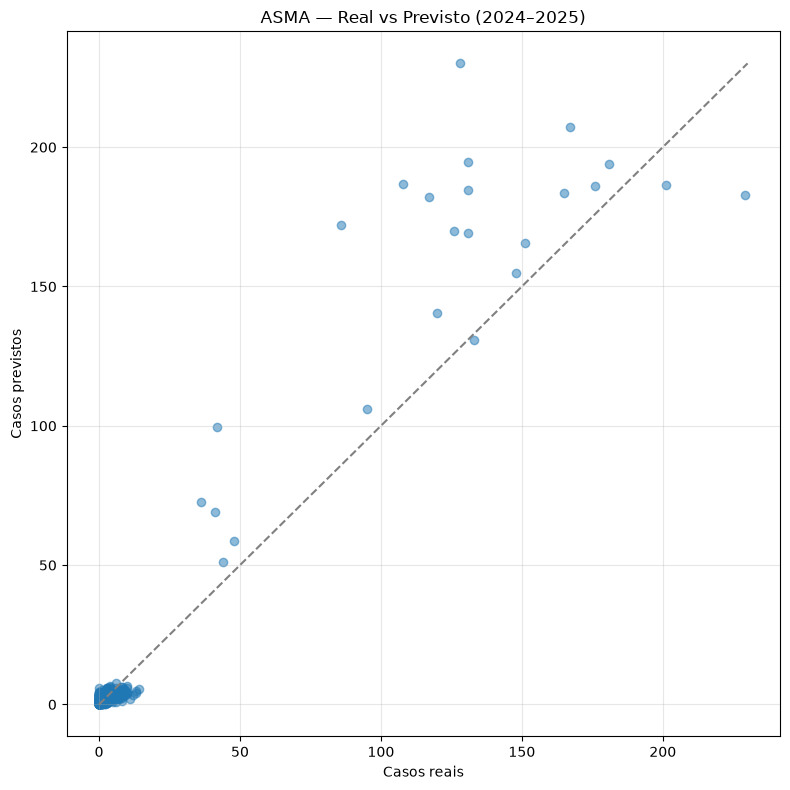

In [29]:
mu.plot_real_vs_predicted(
    resultado["test_final"]["cases"], resultado["final_pred"], DISEASE
)

A maior parte dos pontos se concentra próxima da diagonal para valores baixos de casos, com maior dispersão nos municípios de maior volume (especialmente Porto Alegre), onde o erro absoluto tende a ser maior mesmo quando o erro relativo é comparável.

### B) Backtest temporal por município

`historical_df` contém as linhas de treino (2015–2023) e `forecast_df`
contém as linhas de teste (2024–2025) com a previsão do modelo final.

In [30]:
historical_df = resultado["train_final"]

forecast_df = resultado["test_final"].copy()
forecast_df["prediction"] = resultado["final_pred"]

plot_backtest = mu.make_backtest_plotter(DISEASE, historical_df, forecast_df)

In [31]:
casos_por_municipio_teste = (
    test_disease0.groupby("municipality")["cases"].sum().sort_values(ascending=False)
)

print("Municipios com mais casos de asma no periodo de teste (2024-2025):")
display(casos_por_municipio_teste.head(5))

Municipios com mais casos de asma no periodo de teste (2024-2025):


municipality
PORTO ALEGRE    2935.0
BAGE             163.0
SANTA MARIA      137.0
PASSO FUNDO      107.0
RIO GRANDE        86.0
Name: cases, dtype: float64

Porto Alegre concentra o maior volume de casos de asma (2.935 no teste, muito acima dos demais) e está presente em treino e teste, sendo o primeiro município analisado. Em seguida, Bagé e Santa Maria, segundo e terceiro em volume no teste.

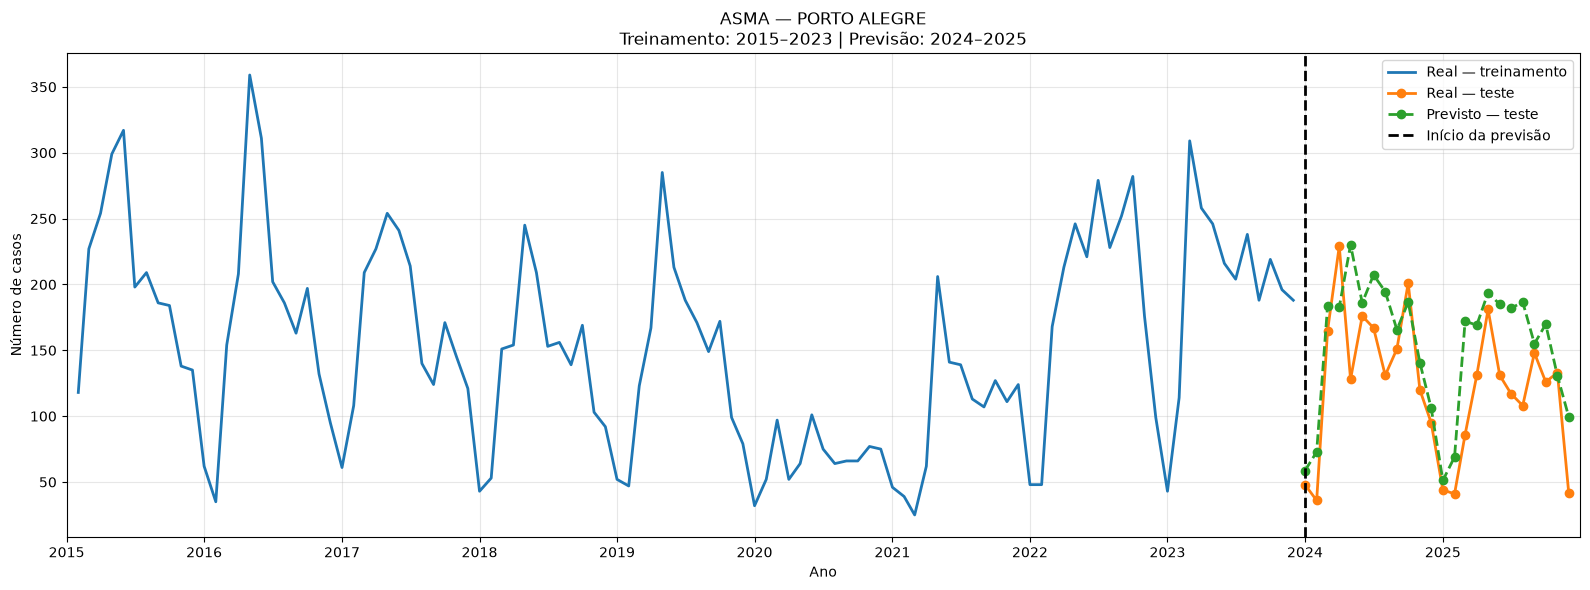

In [32]:
plot_backtest("PORTO ALEGRE")

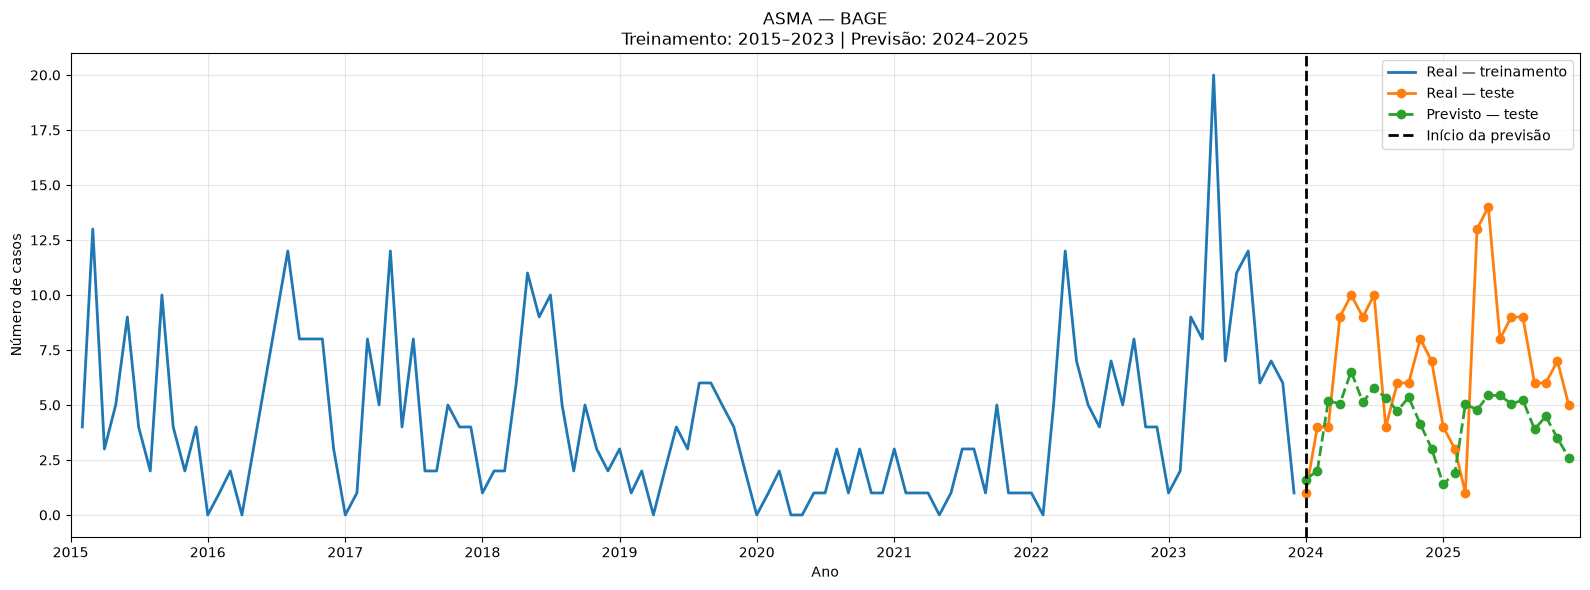

In [33]:
plot_backtest("BAGE")

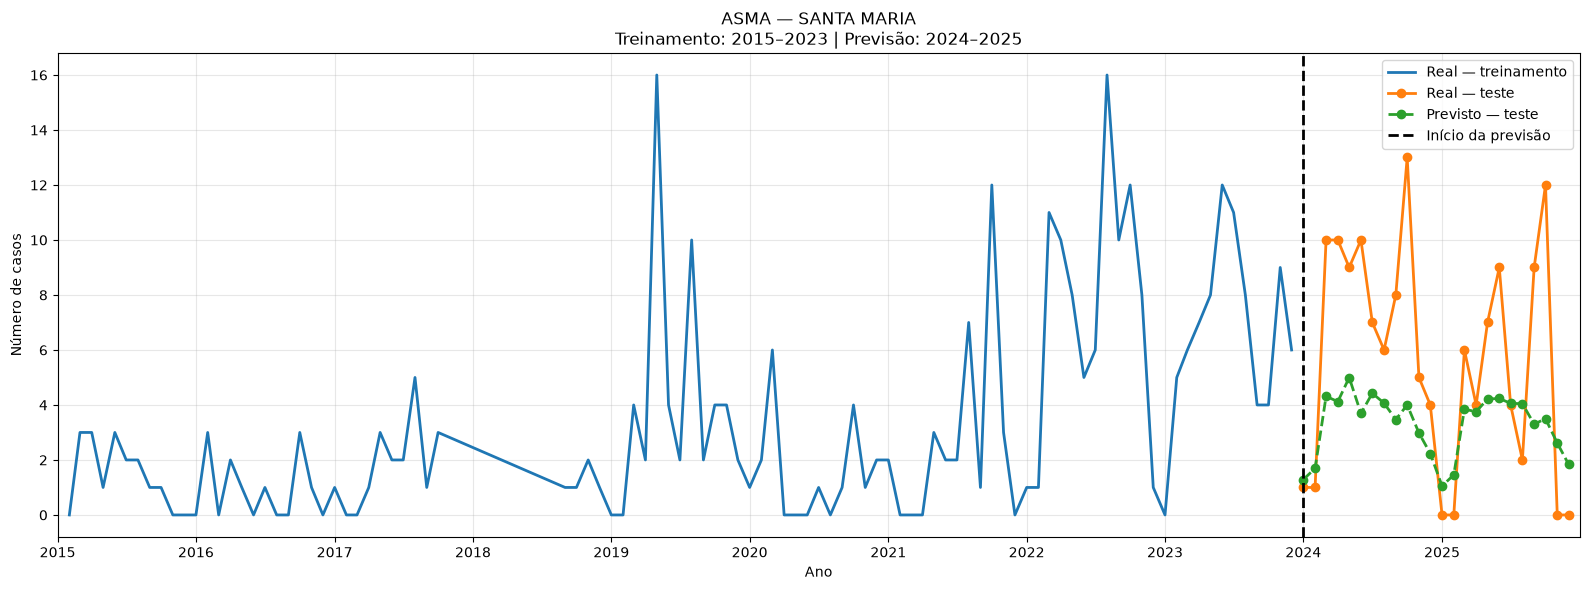

In [34]:
plot_backtest("SANTA MARIA")

### C) Baseline vs. modelo climático vs. real (2024–2025)

Comparação, para Porto Alegre, entre o modelo de referência (município +
mês) e o modelo climático final.

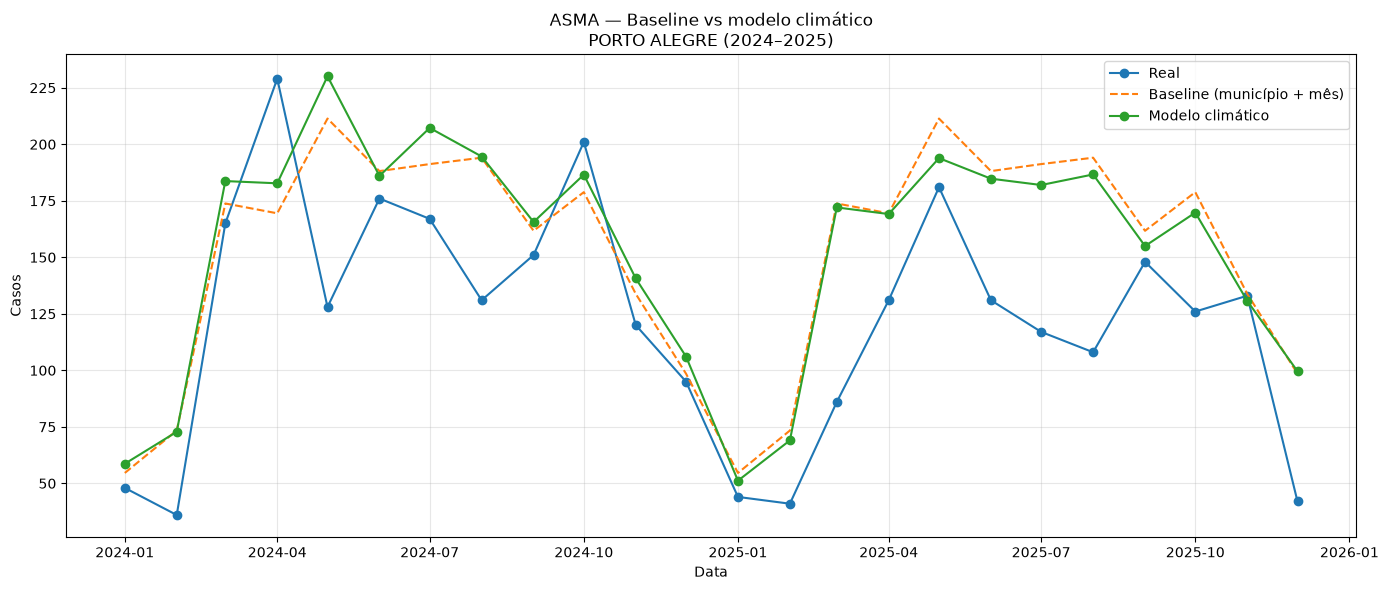

In [35]:
plot_df = resultado["test_final"][
    resultado["test_final"]["municipality"] == "PORTO ALEGRE"
].copy()

plot_df["baseline_pred"] = resultado["base_model"].predict(plot_df)
plot_df["climate_pred"] = resultado["final_model"].predict(plot_df)

mu.plot_baseline_vs_climate(DISEASE, "PORTO ALEGRE", plot_df)

As curvas do baseline e do modelo climático são muito próximas em Porto Alegre, o que é esperado dado o ganho pequeno nas métricas agregadas (MAE≈0,8%, RMSE≈1,5%): praticamente todo o poder explicativo vem da estrutura de município e sazonalidade, com a contribuição climática atuando como um ajuste fino de baixa magnitude.

### D) Tabela de métricas por município

**Atenção**: WAPE e MAE normalizado não devem ser interpretados como "acurácia". Em municípios com poucos casos (ou meses com zero casos), erros absolutos pequenos podem gerar percentuais de erro elevados, mesmo com o modelo capturando bem o padrão geral.

In [36]:
evaluation_df = resultado["test_final"][
    ["municipality", "reference_date", "cases"]
].copy()
evaluation_df["prediction"] = resultado["final_pred"]

municipality_metrics = mu.municipality_metrics_table(evaluation_df)

display(municipality_metrics.sort_values("rmse"))

,municipality,n,mean_cases,mae,rmse,wape_pct,r2
0,CAMBARA DO SUL,24,0.000000,0.123895,0.129695,NaN,NaN
1,CACAPAVA DO SUL,24,0.125000,0.188971,0.333772,151.177120,-0.018550
2,CAMAQUA,22,0.318182,0.553912,0.630665,174.086719,-0.291983
3,CAMPO BOM,20,0.650000,0.641909,0.884104,98.755187,-0.074420
4,CRUZ ALTA,24,1.083333,0.718316,0.905727,66.306062,0.098251
5,LAGOA VERMELHA,24,0.166667,0.932954,1.009889,559.772412,-3.589444
6,CANELA,20,0.800000,0.838471,1.022251,104.808825,0.014154
7,RIO PARDO,24,0.166667,1.047397,1.111459,628.438125,-4.559037
8,TEUTONIA,18,0.222222,1.014610,1.120772,456.574650,-6.267604
9,TORRES,2,1.000000,0.974903,1.253382,97.490280,-0.570967


## Municípios excluídos do backtest

Municípios presentes no teste mas ausentes no treino válido (por dropna nas features climáticas finais) seriam excluídos do backtest e listados aqui, para não inventar categoria nova em `C(municipality)`.

In [37]:
unseen = mu.unseen_municipalities(resultado["train_final"], resultado["test_final"])

municipios_teste_original = set(test_disease0["municipality"].unique())
municipios_teste_final = set(resultado["test_final"]["municipality"].unique())
municipios_perdidos_no_dropna = municipios_teste_original - municipios_teste_final

print("Municípios não vistos no treino (excluídos do backtest):", unseen)
print("Municípios do teste totalmente perdidos pelo dropna das features finais:", municipios_perdidos_no_dropna)
print("Total de municípios excluídos:", len(unseen | municipios_perdidos_no_dropna))

Municípios não vistos no treino (excluídos do backtest): set()
Municípios do teste totalmente perdidos pelo dropna das features finais: set()
Total de municípios excluídos: 0


Para ASMA, nenhum município foi excluído: os 27 municípios do teste também estão no treino válido, e nenhum foi removido por completo pelo dropna das features finais (`relative_humidity_avg_pct`, `dew_point_avg_c_lag1`). Algumas linhas pontuais foram removidas por clima ausente, reduzindo o teste de 648 para 581 linhas, sem eliminar municípios.

## Interpretação final

O modelo de referência (município + mês) já explica a maior parte da variação, reduzindo o MAE do baseline de ≈9,76 para 2,92 apenas com estrutura de município e sazonalidade — esperado, dado o forte componente sazonal da asma e a heterogeneidade entre municípios (Porto Alegre concentra a maioria dos casos).

Entre as variáveis climáticas, a seleção usou 2023 como validação, separada do teste 2024–2025 (nota metodológica acima). `relative_humidity_avg_pct` (contemporânea) e `dew_point_avg_c_lag1` (defasagem de 1 mês) combinaram significância estatística e ganho preditivo fora da amostra de validação, sem problemas de convergência, e são epidemiologicamente coerentes (umidade do ar associada a alérgenos e irritação respiratória). Pressão atmosférica não convergiu e foi descartada; vento e precipitação não mostraram significância. Achado notável: `relative_humidity_avg_pct_lag2` — escolhida em versão anterior que validava no próprio teste 2024–2025 — teve desempenho pior que o modelo-base quando avaliada em 2023, ilustrando o viés que a mudança metodológica elimina.

O modelo final, com essas duas variáveis, converge adequadamente (alpha≈0,345, evidência clara de sobredispersão). Ambas são estatisticamente significativas (p≈0,002) e contribuíram para a previsão dos casos, mas a melhora de desempenho fora da amostra é pequena (MAE≈0,8%, RMSE≈1,5% vs. modelo de referência, em 2024–2025) — menor que a de uma versão anterior (MAE≈1,3%, RMSE≈6,2%) que usava o próprio teste para escolher variáveis. É importante distinguir os dois planos: a associação entre umidade relativa/ponto de orvalho e casos de asma é estatisticamente significativa, mas isso não implica relação causal, nem que o modelo climático seja substancialmente melhor em capacidade preditiva do que apenas conhecer o município e o mês.

Limitações: o modelo não incorpora fatores relevantes não capturados na base (qualidade do ar, queimadas, poluição, fatores individuais) e depende da cobertura das estações meteorológicas usadas nas médias mensais. Nenhum evento extremo foi tratado como caso especial.

## Persistência de artefatos

Resultados salvos em `artifacts/modeling/asma_metrics.json` e `artifacts/modeling/asma_predictions.parquet`, para uso posterior (ex.: notebook consolidado de comparação entre doenças).

In [38]:
metrics = {
    "disease": DISEASE,
    "disease_key": "asma",
    "formula": resultado["formula"],
    "alpha": resultado["alpha"],
    "converged": resultado["final_converged"],
    "base_converged": resultado["base_converged"],
    "aic": final_model.aic,
    "log_likelihood": final_model.llf,
    "coefficients": final_model.params.to_dict(),
    "pvalues": final_model.pvalues.to_dict(),
    "baseline_mae": resultado["base_metrics"]["mae"],
    "baseline_rmse": resultado["base_metrics"]["rmse"],
    "model_mae": resultado["final_metrics"]["mae"],
    "model_rmse": resultado["final_metrics"]["rmse"],
    "mae_improvement_pct": resultado["mae_improvement_pct"],
    "rmse_improvement_pct": resultado["rmse_improvement_pct"],
    "r2_test": resultado["final_metrics"]["r2"],
    "wape_pct": resultado["final_metrics"]["wape_pct"],
    "train_n": len(resultado["train_final"]),
    "test_n": len(resultado["test_final"]),
    "selected_features": features_selecionadas,
    "climate_variable_tests": climate_results.to_dict(orient="records"),
    "lag_variable_tests": lag_results.to_dict(orient="records"),
    "excluded_municipalities": sorted(unseen | municipios_perdidos_no_dropna),
    "feature_selection_rationale": (
        "Selecao feita com validacao em 2023 (train_fs 2015-2022 / validation_fs 2023), "
        "separada do teste final 2024-2025, para evitar reusar o mesmo periodo de teste "
        "tanto para escolher variaveis quanto para reportar performance (viés do "
        "vencedor). Selecionadas relative_humidity_avg_pct (contemporanea) e "
        "dew_point_avg_c_lag1 (defasagem de 1 mes) por combinarem significancia "
        "estatistica na validacao (p=0.0005 e p=0.00005) e no modelo final conjunto "
        "(p=0.0021 e p=0.0023), ganho de MAE/RMSE fora da amostra de validacao, "
        "correlacao praticamente nula entre si (0.017), convergencia do modelo e "
        "coerencia epidemiologica com mecanismos de umidade do ar associados a asma. "
        "atmospheric_pressure_avg_mb nao convergiu no teste individual e foi "
        "descartada; wind_gust_max_ms teve ganho aparente mas sem significancia "
        "estatistica (p=0.37); dew_point_avg_c contemporaneo teve significancia "
        "apenas marginal (p=0.079); relative_humidity_avg_pct_lag2 (selecionada em "
        "versao anterior deste notebook, quando a selecao usava o proprio conjunto "
        "de teste 2024-2025) mostrou ganho negativo de MAE e RMSE na validacao de "
        "2023, ilustrando o viés que esta correcao elimina."
    ),
}

predictions_df = resultado["test_final"][
    ["municipality", "reference_date", "cases"]
].copy()
predictions_df["prediction"] = resultado["final_pred"]

mu.save_disease_artifacts("asma", metrics, predictions_df)

print("Artefatos salvos em artifacts/modeling/asma_metrics.json e artifacts/modeling/asma_predictions.parquet")

Artefatos salvos em artifacts/modeling/asma_metrics.json e artifacts/modeling/asma_predictions.parquet


In [39]:
from pathlib import Path

metrics_path = mu.ARTIFACTS_DIR / "asma_metrics.json"
predictions_path = mu.ARTIFACTS_DIR / "asma_predictions.parquet"

print("Metrics existe:", metrics_path.exists(), metrics_path)
print("Predictions existe:", predictions_path.exists(), predictions_path)

Metrics existe: True C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\artifacts\modeling\asma_metrics.json
Predictions existe: True C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\artifacts\modeling\asma_predictions.parquet
